In [47]:
import os
import numpy as np
import pandas as pd
import folium
import geopandas as gpd
import branca.colormap as cm

os.chdir("/home/abid/binta/walkability_abid/")

from config.grid import GRID_OUT_CSV
from config.dynamic_ws import DYNAMIC_DATA_PATH
from src.composite_score import compute_conf_dyn
from src.plotter import plot_grid
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap


import time
import matplotlib.image as mpimg
from IPython.display import display, clear_output, Image


In [48]:
df_rf = pd.read_csv('redfin_score/redfin.csv')
df_grid = pd.read_csv(GRID_OUT_CSV)



In [49]:
# merge data
df_rf = df_rf.rename(columns={'Walk Score': 'walkscore_redfin'})
df_grid = df_grid.rename(columns={'lat_center': 'lat', 'lon_center': 'lon'})
for d in (df_grid, df_rf):
    d["lat_r6"] = d["lat"].round(6)
    d["lon_r6"] = d["lon"].round(6)
df_merge = df_grid.merge( df_rf, on=["lat_r6", "lon_r6"], how="left", suffixes=("", "_redfin") )
matched_pct = 100 * df_merge["walkscore_redfin"].notna().mean()
print(f"Matched Redfin coverage: {matched_pct:.1f}%")


Matched Redfin coverage: 100.0%


In [50]:
df_merge = df_merge.dropna(subset=[
                                    "walkscore_redfin", 
                                    "walkscore_composite",
                                    "walkscore_static", 
                                    "walkscore_dyn", 
                                    "lat", 
                                    "lon"
                                    ]
                          ).copy()

In [51]:
def metrics(y, x):
    y = pd.to_numeric(y, errors='coerce')
    x = pd.to_numeric(x, errors='coerce')
    m = y.notna() & x.notna()
    y, x = y[m], x[m]
    pear = float(y.corr(x, method="pearson"))
    spear = float(y.corr(x, method="spearman"))
    mae = float(mean_absolute_error(y, x))
    rmse = float(np.sqrt(mean_squared_error(y, x)))
    bias = float((x - y).mean())
    return pd.Series({"pearson_r": round(pear,3), "spearman_rho": round(spear,3),
                      "MAE": round(mae,2), "RMSE": round(rmse,2), "Bias(pred-true)": round(bias,2), "n": len(y)})


In [52]:
# 
m10 = pd.DataFrame({
    "Composite vs Redfin (10m)": metrics(df_merge['walkscore_redfin'], df_merge['walkscore_composite']),
    "Static vs Redfin (10m)"   : metrics(df_merge['walkscore_redfin'], df_merge['walkscore_static']),
    "Dynamic vs Redfin (10m)"  : metrics(df_merge['walkscore_redfin'], df_merge['walkscore_dyn']),
}).T
print(m10)

                           pearson_r  spearman_rho    MAE   RMSE  \
Composite vs Redfin (10m)      0.337         0.302  12.22  15.03   
Static vs Redfin (10m)         0.409         0.338  17.59  20.84   
Dynamic vs Redfin (10m)        0.213         0.242  16.49  20.65   

                           Bias(pred-true)       n  
Composite vs Redfin (10m)            -3.49  1388.0  
Static vs Redfin (10m)              -14.11  1388.0  
Dynamic vs Redfin (10m)               7.21  1388.0  


In [53]:
g = df_merge.copy()
g["lat3"] = g['lat'].round(3)
g["lon3"] = g['lon'].round(3)

agg = g.groupby(["lat3","lon3"]).agg({
    'walkscore_redfin':"mean", 'walkscore_composite':"mean", 'walkscore_static':"mean", 'walkscore_dyn':"mean",
}).reset_index(drop=True)

m100 = pd.DataFrame({
    "Composite vs Redfin (~100m)": metrics(agg['walkscore_redfin'], agg['walkscore_composite']),
    "Static vs Redfin (~100m)"   : metrics(agg['walkscore_redfin'], agg['walkscore_static']),
    "Dynamic vs Redfin (~100m)"  : metrics(agg['walkscore_redfin'], agg['walkscore_dyn']),
}).T
print(m100)

                             pearson_r  spearman_rho    MAE   RMSE  \
Composite vs Redfin (~100m)      0.457         0.443  10.97  13.05   
Static vs Redfin (~100m)         0.497         0.447  16.82  19.92   
Dynamic vs Redfin (~100m)        0.271         0.304  13.68  16.88   

                             Bias(pred-true)     n  
Composite vs Redfin (~100m)            -4.09  66.0  
Static vs Redfin (~100m)              -14.08  66.0  
Dynamic vs Redfin (~100m)               6.26  66.0  


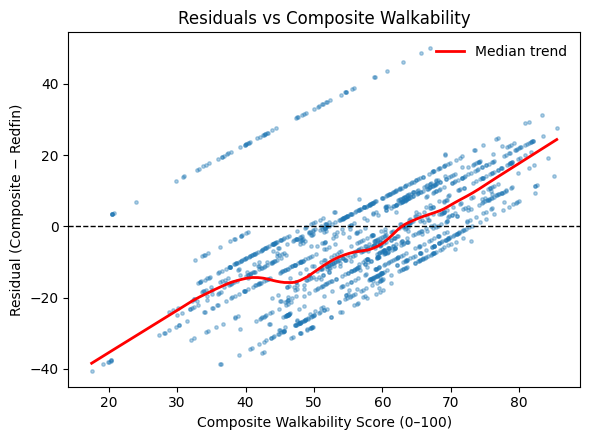

In [54]:
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

df_merge["residual_comp"] = df_merge['walkscore_composite'] - df_merge['walkscore_redfin']

x = df_merge['walkscore_composite']
y = df_merge["residual_comp"]



plt.figure(figsize=(6,4.5))
plt.scatter(
    x, y,
    s=6, alpha=0.35, rasterized=True
)

# Reference line
plt.axhline(0, color='k', lw=1, linestyle='--')

# LOWESS trend (optional but recommended)
mask = np.isfinite(x) & np.isfinite(y)
trend = lowess(y[mask], x[mask], frac=0.25)
plt.plot(trend[:,0], trend[:,1], color='red', lw=2, label="Median trend")

plt.xlabel("Composite Walkability Score (0–100)")
plt.ylabel("Residual (Composite − Redfin)")
plt.title("Residuals vs Composite Walkability")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

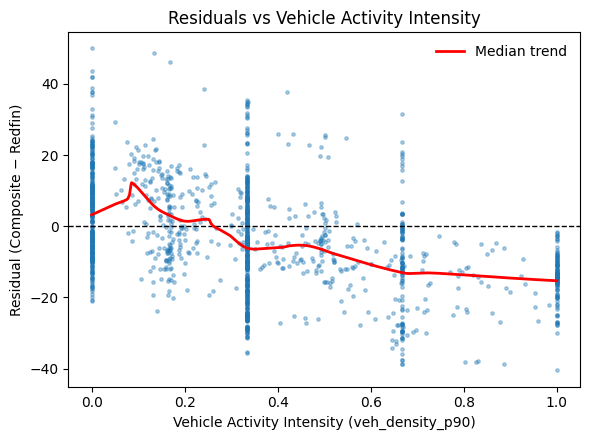

In [55]:
x = pd.to_numeric(df_merge["veh_density_p90"], errors='coerce')
y = df_merge["residual_comp"]

plt.figure(figsize=(6,4.5))
plt.scatter(
    x, y,
    s=6, alpha=0.35, rasterized=True
)

plt.axhline(0, color='k', lw=1, linestyle='--')

# LOWESS trend
mask = np.isfinite(x) & np.isfinite(y)
trend = lowess(y[mask], x[mask], frac=0.35)
plt.plot(trend[:,0], trend[:,1], color='red', lw=2, label="Median trend")

plt.xlabel("Vehicle Activity Intensity (veh_density_p90)")
plt.ylabel("Residual (Composite − Redfin)")
plt.title("Residuals vs Vehicle Activity Intensity")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [56]:
def get_quad(df_merge):
        
    risk_series = df_merge["veh_density_p90"] if "veh_density_p90" in df_merge.columns else pd.Series(np.nan, index=df_merge.index)
    walk_thr = float(df_merge["walkscore_composite"].median(skipna=True))
    risk_thr = float(pd.to_numeric(risk_series, errors='coerce').median(skipna=True))

    def qlabel(w, r):
        """Classify the quadrant based on walkscore and vehicle density."""
        if pd.isna(r): return "Unclassified"
        if w >= walk_thr and r < risk_thr:   return "A: High Walk / Low Vehicle Exposure"
        if w >= walk_thr and r >= risk_thr:  return "B: High Walk / High Vehicle Exposure"
        if w <  walk_thr and r >= risk_thr:  return "C: Low Walk / High Vehicle Exposure"
        return "D: Low Walk / Low Vehicle Exposure"

    df_merge["quad_class"] = [qlabel(w, r) for w, r in zip(df_merge["walkscore_composite"], risk_series)]

    def metrics_series(sub):
        return metrics(sub["walkscore_redfin"], sub["walkscore_composite"])
    by_quad = df_merge.dropna(subset=["walkscore_redfin", "walkscore_composite"]).groupby("quad_class").apply(metrics_series)
    return df_merge, by_quad


In [57]:
df_merge, by_quad = get_quad(df_merge)

/tmp/ipykernel_1223188/3104660313.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_quad = df_merge.dropna(subset=["walkscore_redfin", "walkscore_composite"]).groupby("quad_class").apply(metrics_series)


In [58]:


colors = ['#e6194B', '#3cb44b', '#ffe119', '#4363d8'] 

# 2. Create the discrete colormap
cmap = cm.linear.RdYlGn_09.scale(0, 3).to_step(4)
# plot_grid(df_merge, "quad.html","quad_class","Quad Class", cmap=cmap)

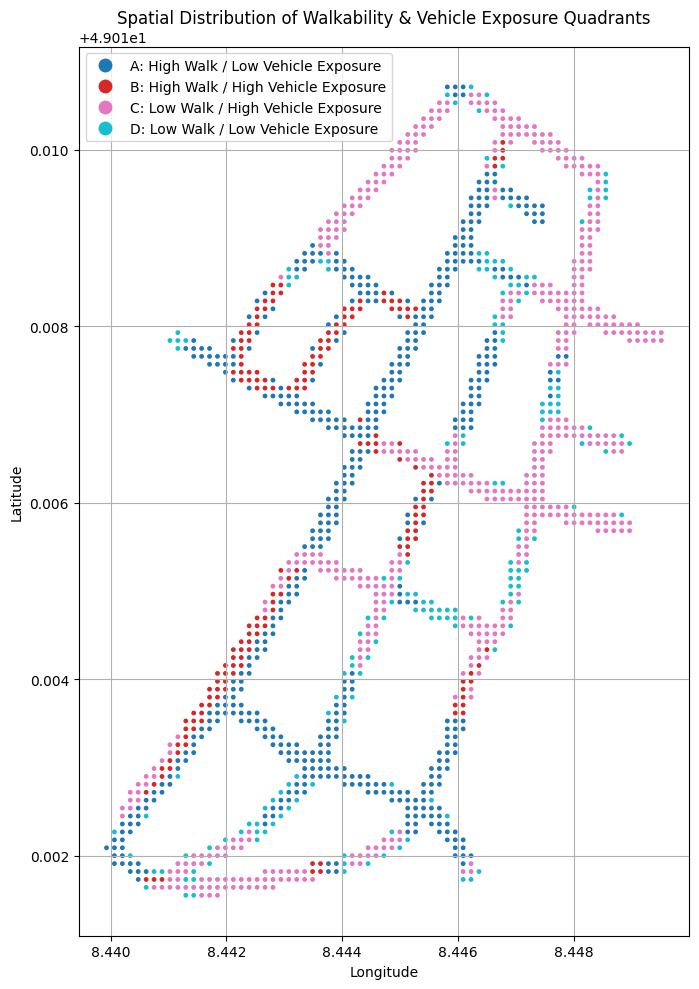

In [59]:


# Drop rows with missing quadrant classes or coordinates
df_quad = df_merge.dropna(subset=["quad_class", "lat", "lon"]).copy()

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_quad,
    geometry=gpd.points_from_xy(df_quad["lon"], df_quad["lat"]),
    crs="EPSG:4326"
)

# Plotting quadrant class distribution
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, column="quad_class", legend=True, categorical=True, markersize=6)
plt.title("Spatial Distribution of Walkability & Vehicle Exposure Quadrants")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()

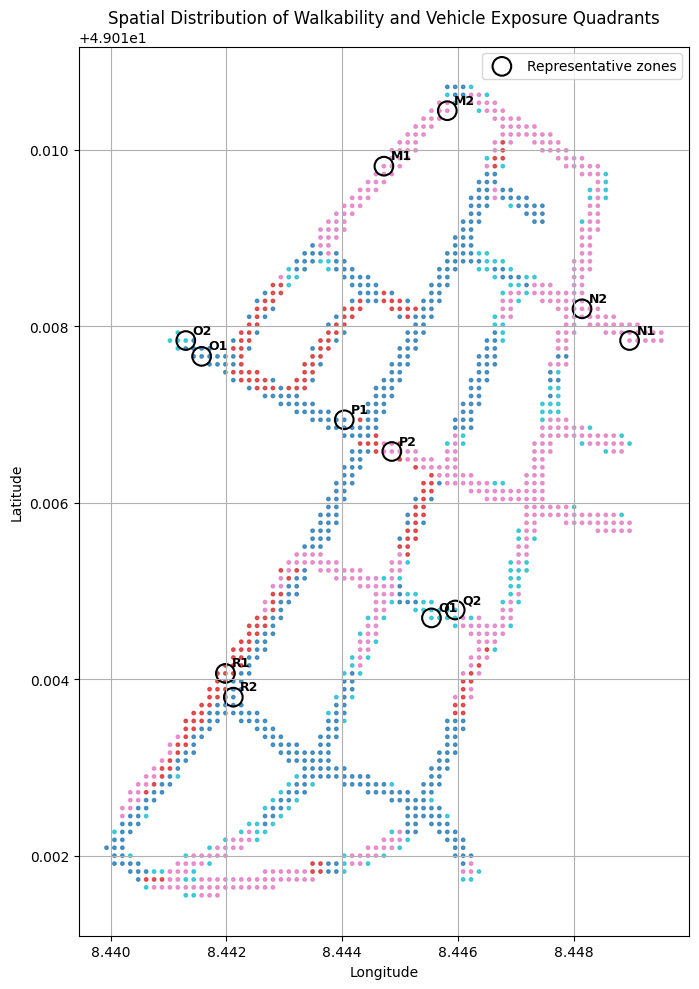

In [60]:


# Drop rows with missing quadrant classes or coordinates
df_quad = df_merge.dropna(subset=["quad_class", "lat", "lon"]).copy()

# Create GeoDataFrame for all grid cells
gdf = gpd.GeoDataFrame(
    df_quad,
    geometry=gpd.points_from_xy(df_quad["lon"], df_quad["lat"]),
    crs="EPSG:4326"
)

# Representative zone points
zone_points = [
    ("M1", 49.01981504817049, 8.44472124756990),
    ("M2", 49.02044386886938, 8.445817007663248),
    ("N1", 49.01783875454543, 8.44896731793162),
    ("N2", 49.01819808065908, 8.44814549786161),
    ("O1", 49.01765909148860, 8.441570937301526),
    ("O2", 49.01783875454543, 8.44129699727819),
    ("P1", 49.01694043926131, 8.444036397511558),
    ("P2", 49.01658111314766, 8.444858217581569),
    ("Q1", 49.01469465105101, 8.44554306763991),
    ("Q2", 49.01478448257942, 8.445953977674916),
    ("R1", 49.01406583035212, 8.441981847336532),
    ("R2", 49.01379633576689, 8.44211881734820),
]

df_zones = pd.DataFrame(zone_points, columns=["zone_label", "lat", "lon"])

gdf_zones = gpd.GeoDataFrame(
    df_zones,
    geometry=gpd.points_from_xy(df_zones["lon"], df_zones["lat"]),
    crs="EPSG:4326"
)

# Plotting quadrant class distribution
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    column="quad_class",
    legend=True,
    categorical=True,
    markersize=6,
    alpha=0.75
)

# Plot representative zones as circles
gdf_zones.plot(
    ax=ax,
    marker="o",
    facecolor="none",
    edgecolor="black",
    linewidth=1.5,
    markersize=180,
    label="Representative zones"
)

# Add zone labels
for _, row in gdf_zones.iterrows():
    ax.annotate(
        row["zone_label"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        color="black"
    )

plt.title("Spatial Distribution of Walkability and Vehicle Exposure Quadrants")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


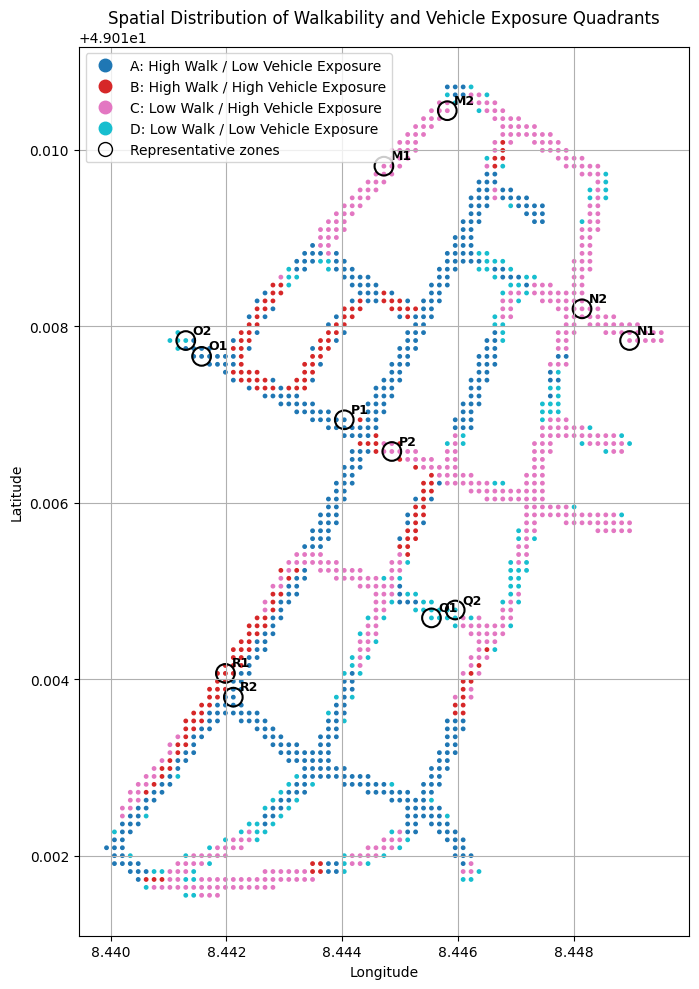

In [61]:

quad_colors = {
    "A": "tab:blue",
    "B": "tab:red",
    "C": "tab:pink",
    "D": "tab:cyan",
}

quad_labels = {
    "A": "A: High Walk / Low Vehicle Exposure",
    "B": "B: High Walk / High Vehicle Exposure",
    "C": "C: Low Walk / High Vehicle Exposure",
    "D": "D: Low Walk / Low Vehicle Exposure",
}

gdf["quad_color"] = gdf["quad_class"].map(quad_colors)

fig, ax = plt.subplots(figsize=(10, 10))

# Plot quadrant points
gdf.plot(ax=ax, column="quad_class", legend=True, categorical=True, markersize=6)
# Plot representative zones as circles
gdf_zones.plot(
    ax=ax,
    marker="o",
    facecolor="none",
    edgecolor="black",
    linewidth=1.5,
    markersize=180,
    label="Representative zones"
)

# Add zone labels
for _, row in gdf_zones.iterrows():
    ax.annotate(
        row["zone_label"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        color="black"
    )

# Custom legend for quadrant classes
legend_elements = [
    Line2D([0], [0], marker="o", color="w",
           label=quad_labels[q],
           markerfacecolor=quad_colors[q],
           markeredgecolor=quad_colors[q],
           markersize=9)
    for q in ["A", "B", "C", "D"]
]

# Add representative zone legend
legend_elements.append(
    Line2D([0], [0], marker="o", color="black",
           label="Representative zones",
           markerfacecolor="none",
           markeredgecolor="black",
           markersize=10,
           linewidth=0)
)

ax.legend(handles=legend_elements, loc="upper left")

plt.title("Spatial Distribution of Walkability and Vehicle Exposure Quadrants")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()

In [62]:


# Drop rows with missing quadrant classes or coordinates
df_quad = df_merge.dropna(subset=["quad_class", "lat", "lon"]).copy()

# Extract quadrant letter from values like:
# "A: High Walk / Low Vehicle Exposure"
df_quad["quad_id"] = df_quad["quad_class"].astype(str).str.extract(r"^([A-D])")[0]

# Fixed colors and labels
quad_colors = {
    "A": "green",
    "B": "red",
    "C": "orange",
    "D": "yellow"
}

quad_labels = {
    "A": "High Walk / Low Vehicle Exposure",
    "B": "High Walk / High Vehicle Exposure",
    "C": "Low Walk / High Vehicle Exposure",
    "D": "Low Walk / Low Vehicle Exposure"
}

# Map center
center_lat = df_quad["lat"].mean()
center_lon = df_quad["lon"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=16,
    tiles="CartoDB positron"
)

# Add grid-cell points
for _, row in df_quad.iterrows():
    q = row["quad_id"]

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=3,
        color=quad_colors.get(q, "gray"),
        fill=True,
        fill_color=quad_colors.get(q, "gray"),
        fill_opacity=0.75,
        popup=f"""
        <b>Quadrant:</b> {q}<br>
        <b>Meaning:</b> {quad_labels.get(q, 'Unknown')}<br>
        <b>Lat:</b> {row['lat']}<br>
        <b>Lon:</b> {row['lon']}
        """
    ).add_to(m)

# Add legend
legend_html = """
<div style="
position: fixed;
bottom: 40px;
left: 40px;
width: 300px;
background-color: white;
border:2px solid grey;
z-index:9999;
font-size:14px;
padding: 10px;
">
<b>Quadrant Classes</b><br>
<span style="color:green;">●</span> A: High Walk / Low Vehicle Exposure<br>
<span style="color:red;">●</span> B: High Walk / High Vehicle Exposure<br>
<span style="color:orange;">●</span> C: Low Walk / High Vehicle Exposure<br>
<span style="color:yellow;">●</span> D: Low Walk / Low Vehicle Exposure
</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))


os.makedirs("outputs", exist_ok=True)
m.save("outputs/walkability_quadrant_map.html")
# m
# # Save and display map in notebook
# m.save("output/walkability_quadrant_map.html")


In [63]:
# Ensure quad id exists (A-D)
df_merge['quad_id'] = df_merge['quad_class'].astype(str).str.extract(r'^([A-D])')[0]



In [64]:
# Compute per-quadrant summary using walkscore_composite and vehicle intensity
# Ensure quad id exists (A-D)
df_merge['quad_id'] = df_merge['quad_class'].astype(str).str.extract(r'^([A-D])')[0]

# select vehicle column (user indicated vehicle_density_p90 / veh_density_p90)
veh_col = 'veh_density_p90' if 'veh_density_p90' in df_merge.columns else ('veh_density_n_std' if 'veh_density_n_std' in df_merge.columns else None)
if veh_col:
    df_merge['veh_for_summary'] = pd.to_numeric(df_merge[veh_col], errors='coerce')
else:
    df_merge['veh_for_summary'] = pd.NA

# aggregate mean and std of composite walkscore and mean vehicle intensity per quadrant
summary = df_merge.dropna(subset=['quad_id']).groupby('quad_id').agg(
    walkscore_mean=('walkscore_composite','median'),
    walkscore_std =('walkscore_composite','std'),
    veh_density_mean=('veh_for_summary','mean')
).round(3).reset_index()

# map full labels if available and reorder columns for display
if 'quad_labels' in globals():
    summary['quad_label'] = summary['quad_id'].map(lambda q: quad_labels.get(q, q))
    summary = summary[['quad_id','quad_label','walkscore_mean','walkscore_std','veh_density_mean']]

print(summary.to_string(index=False))

quad_id                        quad_label  walkscore_mean  walkscore_std  veh_density_mean
      A  High Walk / Low Vehicle Exposure          67.294          6.830             0.093
      B High Walk / High Vehicle Exposure          62.176          4.065             0.481
      C  Low Walk / High Vehicle Exposure          46.150          8.047             0.591
      D   Low Walk / Low Vehicle Exposure          51.079          6.438             0.201


In [65]:
df_merge['walkscore_composite'].max()


85.50276720643716

In [66]:
df_merge.keys()

Index(['ix', 'iy', 'x_center', 'y_center', 'frames_contrib', 'frame_ids',
       'conf_dyn', 'ped_density', 'veh_density', 'ped_exposure',
       ...
       'dyn_v2_ci90_high', 'dyn_v2_ci90_width', 'alpha_adj',
       'walkscore_composite_adj', 'Unnamed: 54', 'walkscore_redfin',
       'residual_comp', 'quad_class', 'quad_id', 'veh_for_summary'],
      dtype='object', length=101)

In [67]:
quad_grouped = (
    df_merge.dropna(subset=["quad_id"])
    .groupby("quad_id")["frame_ids"]
    .apply(list)
    .reset_index(name="frame_list")
)

quad_grouped

,quad_id,frame_list
0,A,[8585;8586;8587;8588;8589;8590;8591;8622;8623;...
1,B,[8581;8582;8583;8584;8585;8586;8587;8588;8589;...
2,C,[10262;10263;10264;10265;10266;10267;10268;102...
3,D,[10268;10269;10271;10272;10273;10274;10275;102...


In [68]:
# KITTI-360 image folder
img_dir = r"/home/abid/binta/KITTI_360/download_2d_perspective/KITTI-360/data_2d_raw/2013_05_28_drive_0000_sync/image_00/data_rect"

In [69]:
def frame_to_path(frame_id):
    return os.path.join(img_dir, f"{int(frame_id):010d}.png")

def flatten_frame_list(frame_list):
    frames = []

    for item in frame_list:
        if pd.isna(item):
            continue

        for frame in str(item).split(";"):
            frame = frame.strip()
            if frame:
                frames.append(int(frame))

    return sorted(set(frames))

def play_frames(frame_list, fps=5, max_frames=None):
    frames = flatten_frame_list(frame_list)

    if max_frames is not None:
        frames = frames[:max_frames]

    for frame_id in frames:
        img_path = frame_to_path(frame_id)

        clear_output(wait=True)

        if os.path.exists(img_path):
            display(Image(filename=img_path))
            print(f"Frame: {frame_id}")
        else:
            print(f"Missing image: {img_path}")

        time.sleep(1 / fps)

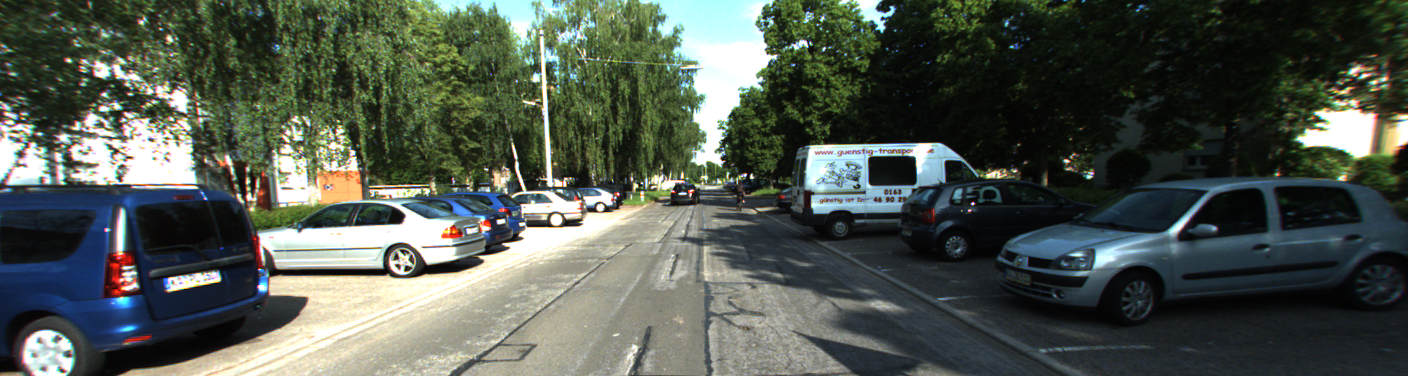

Frame: 2158


In [70]:
frames_A = quad_grouped.loc[quad_grouped["quad_id"] == "A", "frame_list"].iloc[0]
#play_frames(frames_A, fps=1, max_frames=None)
#Play all frames in that quadrant at 1 images per second. 
play_frames(frames_A, fps=10, max_frames=200)
#Fast: 10 images per second, up to 200 images.

In [71]:
quad_labels = {
    "A": "High Walk / Low Vehicle Exposure",
    "B": "High Walk / High Vehicle Exposure",
    "C": "Low Walk / High Vehicle Exposure",
    "D": "Low Walk / Low Vehicle Exposure"
}

quad_colors = {
    "A": "green",
    "B": "red",
    "C": "orange",
    "D": "gold"
}

def frame_to_path(frame_id):
    return os.path.join(img_dir, f"{int(frame_id):010d}.png")

def flatten_frame_list(frame_list):
    frames = []

    for item in frame_list:
        if pd.isna(item):
            continue

        for frame in str(item).split(";"):
            frame = frame.strip()
            if frame:
                frames.append(int(frame))

    return sorted(set(frames))

# Pick correct quadrant column
quad_col = "quad_id" if "quad_id" in quad_grouped.columns else "quad"

# Build frame dictionary for A-D
quad_frames = {}

for q in ["A", "B", "C", "D"]:
    rows = quad_grouped.loc[quad_grouped[quad_col] == q, "frame_list"]

    if len(rows) > 0:
        quad_frames[q] = flatten_frame_list(rows.iloc[0])
    else:
        quad_frames[q] = []

def plot_quad_videos(quad_frames, fps=5, max_frames=100):
    n_frames = max(len(v) for v in quad_frames.values())

    if max_frames is not None:
        n_frames = min(n_frames, max_frames)

    for i in range(n_frames):
        clear_output(wait=True)

        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        axes = axes.ravel()

        for ax, q in zip(axes, ["A", "B", "C", "D"]):
            frames = quad_frames[q]

            ax.axis("off")

            if len(frames) == 0:
                ax.set_title(f"{q}: {quad_labels[q]}\nNo frames", color=quad_colors[q])
                continue

            frame_id = frames[min(i, len(frames) - 1)]
            img_path = frame_to_path(frame_id)

            if os.path.exists(img_path):
                img = mpimg.imread(img_path)
                ax.imshow(img)
                ax.set_title(
                    f"{q}: {quad_labels[q]}\nFrame {frame_id}",
                    color=quad_colors[q],
                    fontsize=11,
                    fontweight="bold"
                )
            else:
                ax.set_title(
                    f"{q}: {quad_labels[q]}\nMissing frame {frame_id}",
                    color=quad_colors[q],
                    fontsize=11,
                    fontweight="bold"
                )

        plt.tight_layout()
        display(fig)
        plt.close(fig)

        time.sleep(1 / fps)

In [72]:
# plot_quad_videos(quad_frames, fps=5, max_frames=100)
#plot_quad_videos(quad_frames, fps=1, max_frames=None)

In [73]:
df_merge.head()

,ix,iy,x_center,y_center,frames_contrib,frame_ids,conf_dyn,ped_density,veh_density,ped_exposure,...,dyn_v2_ci90_high,dyn_v2_ci90_width,alpha_adj,walkscore_composite_adj,Unnamed: 54,walkscore_redfin,residual_comp,quad_class,quad_id,veh_for_summary
0,10,0,-277.640922,-496.166397,9,10268;10269;10271;10272;10273;10274;10275;1027...,0.051638,0.0,0.099893,0.0,...,-0.351553,0.000000,0.089571,35.195521,NaN,75,-30.796725,D: Low Walk / Low Vehicle Exposure,D,0.333333
1,11,0,-267.640922,-496.166397,9,10265;10266;10267;10268;10269;10271;10272;1027...,0.058311,0.0,0.099893,0.0,...,-0.351553,0.319806,0.087451,32.657353,NaN,75,-31.046529,D: Low Walk / Low Vehicle Exposure,D,0.333333
2,12,0,-257.640922,-496.166397,9,10262;10263;10264;10265;10266;10267;10268;1026...,0.064592,0.0,0.166488,0.0,...,-0.671359,0.000000,0.097307,32.605107,NaN,75,-29.411754,C: Low Walk / High Vehicle Exposure,C,0.666667
3,13,0,-247.640922,-496.166397,8,10260;10261;10262;10263;10264;10265;10266;10267,0.062275,0.0,0.199786,0.0,...,-0.671359,0.000000,0.091187,30.733477,NaN,75,-31.309866,C: Low Walk / High Vehicle Exposure,C,0.666667
4,14,0,-237.640922,-496.166397,8,10257;10258;10259;10260;10261;10262;10263;10264,0.056367,0.0,0.199786,0.0,...,-0.671359,0.000000,0.087052,35.013065,NaN,75,-27.620353,C: Low Walk / High Vehicle Exposure,C,0.666667


In [74]:
df_merge["walkscore_composite"]

0       44.203275
1       43.953471
2       45.588246
3       43.690134
4       47.379647
          ...    
1383    51.964668
1384    58.058107
1385    65.192941
1386    65.895297
1387    49.703762
Name: walkscore_composite, Length: 1388, dtype: float64

In [75]:
os.makedirs("outputs", exist_ok=True)

df_merge.to_csv("outputs/df_merge_redfin.csv", index=False)

print("Saved: outputs/df_merge_redfin.csv")
print(df_merge.shape)

Saved: outputs/df_merge_redfin.csv
(1388, 101)


In [77]:
walk_thr = df_merge["walkscore_composite"].median(skipna=True)
walk_thr

57.54032136672034

In [ ]:
risk_thr = pd.to_numeric(df_merge["veh_density_p90"], errors="coerce").median(skipna=True)
risk_thr

0.9999999995353888